In [96]:
import pandas as pd
import numpy as np
from datetime import datetime
import seaborn as sns
import matplotlib.pyplot as plt

## Nivel 1

### Ejercicio 1

In [97]:
# Leemos el archivo para crear el df, asignamos el nombre de las columnas (se encuentra en la cuarta fila del archivo) y la primera columna se usará como índice
df_personas = pd.read_excel("sprint10.xlsx", header=3, index_col= 0)

# Ordenar dataframe por país/ciudad de origen
df_personas = df_personas.sort_values(by=['País d\'origen','Ciutat'])

df_personas

,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional
21,Mia,Schneider Fischer,28973553Z,Alemanya,Berlín,22,10,1976,A,951 €,NaN,1.0,Grup A
154,Laura,Schneider Fischer,37399141L,Alemanya,Berlín,2,2,1958,D,1.769 €,1.0,NaN,Grup B
224,Lea,Schneider Schneider,37368317L,Alemanya,Berlín,23,10,2005,D,2.013 €,NaN,1.0,Grup B
278,Mia,Fischer,21390098Z,Alemanya,Berlín,11,8,1950,D,1.557 €,1.0,NaN,Grup B
602,Jonas,Schneider,44060014R,Alemanya,Berlín,22,11,1985,H,2.754 €,1.0,NaN,Grup D
...,...,...,...,...,...,...,...,...,...,...,...,...,...
547,Emily,Taylor Jones,89577876S,Regne Unit,Manchester,28,3,1958,D,2.033 €,NaN,1.0,Grup B
728,George,Brown Jones,57441590Y,Regne Unit,Manchester,27,12,1979,H,1.130 €,1.0,NaN,Grup A
751,Olivia,Brown Brown,58204038A,Regne Unit,Manchester,28,8,1952,A,1.023 €,NaN,1.0,Grup A
854,Isla,Jones Brown,28367234K,Regne Unit,Manchester,28,3,1999,D,1.197 €,NaN,1.0,Grup A


In [98]:
# Mostramos las primeras 10 filas
df_personas.head(10)

,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional
21,Mia,Schneider Fischer,28973553Z,Alemanya,Berlín,22,10,1976,A,951 €,NaN,1.0,Grup A
154,Laura,Schneider Fischer,37399141L,Alemanya,Berlín,2,2,1958,D,1.769 €,1.0,NaN,Grup B
224,Lea,Schneider Schneider,37368317L,Alemanya,Berlín,23,10,2005,D,2.013 €,NaN,1.0,Grup B
278,Mia,Fischer,21390098Z,Alemanya,Berlín,11,8,1950,D,1.557 €,1.0,NaN,Grup B
602,Jonas,Schneider,44060014R,Alemanya,Berlín,22,11,1985,H,2.754 €,1.0,NaN,Grup D
871,Lea,Fischer,14773153R,Alemanya,Berlín,9,9,1986,D,1.370 €,1.0,NaN,Grup A
281,Lea,Müller,23266650S,Alemanya,Hamburg,14,4,2003,D,1.314 €,NaN,1.0,Grup A
435,Anna,Müller,83274277X,Alemanya,Hamburg,1,1,1987,D,2.464 €,NaN,1.0,Grup C
444,Laura,Schmidt Müller,60161784X,Alemanya,Hamburg,15,6,1987,NC,2.035 €,1.0,NaN,Grup C
487,Lukas,Müller Fischer,60982309S,Alemanya,Hamburg,28,3,1971,H,2.042 €,NaN,1.0,Grup B


In [99]:
# Imprimimos un mensaje donde nos confirme que todos los valores de la columna DNI son únicos
print(f"Todos los valores de DNI són únicos?: {len(df_personas['DNI']) == len(df_personas['DNI'].unique())}")

Todos los valores de DNI són únicos?: True


### Ejercicio 2

In [100]:
# Crear una columna con el nombre completo
df_personas['Nom_sencer'] = df_personas['Nom'].str.cat(df_personas['Cognoms'], sep=' ')

# Nacido/a en España: Si/No
df_personas.loc[df_personas['País d\'origen'] == 'Espanya', 'Nascut_Espanya'] = 'Si'
df_personas.loc[df_personas['País d\'origen'] != 'Espanya', 'Nascut_Espanya'] = 'No'

# Poner el DNI como índice del df: Lo pongo en comentario porque una vez aplicado, me da error si se vuelve a ejecutar
df_personas.set_index(['DNI'], inplace= True)

# Substituir el nombre de las columnas de nacimiento por "Dia", "Mes" y "Any"
df_personas.rename(columns={'Dia de Naixement':'Dia','Mes de Naixement':'Mes','Any de Naixement':'Any'}, inplace=True)

# Substituir género de H, D, A y NC (para nan,null,na)
df_personas['Gènere'] = df_personas['Gènere'].replace(to_replace=['H','D','A','NC'], value=['Home','Dona','Altres', np.nan])

df_personas

,Nom,Cognoms,País d'origen,Ciutat,Dia,Mes,Any,Gènere,Salari mensual,Fills,No Fills,Grup Professional,Nom_sencer,Nascut_Espanya
DNI,,,,,,,,,,,,,,
28973553Z,Mia,Schneider Fischer,Alemanya,Berlín,22,10,1976,Altres,951 €,NaN,1.0,Grup A,Mia Schneider Fischer,No
37399141L,Laura,Schneider Fischer,Alemanya,Berlín,2,2,1958,Dona,1.769 €,1.0,NaN,Grup B,Laura Schneider Fischer,No
37368317L,Lea,Schneider Schneider,Alemanya,Berlín,23,10,2005,Dona,2.013 €,NaN,1.0,Grup B,Lea Schneider Schneider,No
21390098Z,Mia,Fischer,Alemanya,Berlín,11,8,1950,Dona,1.557 €,1.0,NaN,Grup B,Mia Fischer,No
44060014R,Jonas,Schneider,Alemanya,Berlín,22,11,1985,Home,2.754 €,1.0,NaN,Grup D,Jonas Schneider,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89577876S,Emily,Taylor Jones,Regne Unit,Manchester,28,3,1958,Dona,2.033 €,NaN,1.0,Grup B,Emily Taylor Jones,No
57441590Y,George,Brown Jones,Regne Unit,Manchester,27,12,1979,Home,1.130 €,1.0,NaN,Grup A,George Brown Jones,No
58204038A,Olivia,Brown Brown,Regne Unit,Manchester,28,8,1952,Altres,1.023 €,NaN,1.0,Grup A,Olivia Brown Brown,No


### Ejercicio 3

In [101]:
# Mediante el método apply(), creamos una nueva columna que resuma si la persona tiene hijos o no
df_personas['Fills_nuevo']= df_personas['Fills'].apply(lambda hijos: 'Si' if hijos == 1 else 'No')

df_personas

,Nom,Cognoms,País d'origen,Ciutat,Dia,Mes,Any,Gènere,Salari mensual,Fills,No Fills,Grup Professional,Nom_sencer,Nascut_Espanya,Fills_nuevo
DNI,,,,,,,,,,,,,,,
28973553Z,Mia,Schneider Fischer,Alemanya,Berlín,22,10,1976,Altres,951 €,NaN,1.0,Grup A,Mia Schneider Fischer,No,No
37399141L,Laura,Schneider Fischer,Alemanya,Berlín,2,2,1958,Dona,1.769 €,1.0,NaN,Grup B,Laura Schneider Fischer,No,Si
37368317L,Lea,Schneider Schneider,Alemanya,Berlín,23,10,2005,Dona,2.013 €,NaN,1.0,Grup B,Lea Schneider Schneider,No,No
21390098Z,Mia,Fischer,Alemanya,Berlín,11,8,1950,Dona,1.557 €,1.0,NaN,Grup B,Mia Fischer,No,Si
44060014R,Jonas,Schneider,Alemanya,Berlín,22,11,1985,Home,2.754 €,1.0,NaN,Grup D,Jonas Schneider,No,Si
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89577876S,Emily,Taylor Jones,Regne Unit,Manchester,28,3,1958,Dona,2.033 €,NaN,1.0,Grup B,Emily Taylor Jones,No,No
57441590Y,George,Brown Jones,Regne Unit,Manchester,27,12,1979,Home,1.130 €,1.0,NaN,Grup A,George Brown Jones,No,Si
58204038A,Olivia,Brown Brown,Regne Unit,Manchester,28,8,1952,Altres,1.023 €,NaN,1.0,Grup A,Olivia Brown Brown,No,No


### Ejercicio 4

In [102]:
# Crear una tabla resumen que nos permita ver el sueldo medio, mediano, máximo y mínimo por género
# Primero he creado una columna nueva con el sueldo limpio y en formato numérico para poder aplicar las funciones de agregación
df_personas['Salari_int'] = df_personas['Salari mensual'].str.replace(r'[^\d.]','',regex= True).str.replace(".", "", regex=False).astype(int)

df_sueldos = df_personas.groupby(df_personas['Gènere'].fillna('No info'))['Salari_int'].aggregate(['mean','median','min','max']).round() # -- He convertido los NaN en 'No info' porque sino no me aparecían sus valores

# Ordenar la nueva tabla por sueldo medio
sueldos_ordenados = df_sueldos.sort_values('mean', ascending=False)
sueldos_ordenados

,mean,median,min,max
Gènere,,,,
Home,1643.0,1531.0,737,3356
Altres,1627.0,1545.0,703,3175
No info,1569.0,1443.0,758,2969
Dona,1469.0,1362.0,665,3021


### Ejercicio 5

In [103]:
# Crear una tabla resumen del salario medio por género y país de origen
df_personas['Gènere'] = df_personas['Gènere'].fillna('No info')
df_sueldo_pais = df_personas.pivot_table(values='Salari_int', index='Gènere',columns='País d\'origen',aggfunc='mean',margins=True, margins_name='Mitja_total').round(2)

# Aplicar un color condicional a los valores más elevados
df_styled = df_sueldo_pais.style.format("{:.2f}").background_gradient(cmap='Blues')
df_styled

País d'origen,Alemanya,Argentina,Colòmbia,Espanya,França,Itàlia,Marroc,Mèxic,Portugal,Regne Unit,Mitja_total
Gènere,,,,,,,,,,,
Altres,951.00,1141.00,1030.00,1706.18,nan,1423.00,1365.00,1372.00,1765.00,1921.00,1626.59
Dona,1804.31,1291.80,1497.75,1460.16,1566.47,1247.18,1405.21,1517.80,1488.55,1489.46,1469.44
Home,2067.43,1583.29,1554.67,1682.11,1389.25,1672.88,1531.00,1625.00,1497.00,1162.56,1643.25
No info,1931.50,1135.67,1252.00,1597.14,1573.00,1316.00,1365.50,1583.00,1553.50,1758.00,1568.87
Mitja_total,1858.35,1431.68,1489.13,1582.16,1465.36,1421.17,1441.69,1559.08,1527.23,1448.33,1561.46


### Ejercicio 6

In [104]:
# Crea una columna que sea la fecha de nacimiento en formato datetime y utiliza esta columna para crear una función que, dada la fecha de nacimiento, calcule la edad actual
df_personas['Data_naixement'] = pd.to_datetime({
    'year': df_personas['Any'],
    'month': df_personas['Mes'],
    'day': df_personas['Dia']
})

def edad(nacimiento):
    hoy = datetime.now()
    edad = hoy.year - nacimiento.year
    # Revisar si el mes y dia de cumpleaños ya han pasado para restar o no un año a la edad, y no solo basarnos en el año de nacimiento
    if (hoy.month,hoy.day) < (nacimiento.month,nacimiento.day):
        edad -= 1
    return edad

# Utiliza la función para crear una nueva columna con la edad actual
df_personas['Edat'] = df_personas['Data_naixement'].apply(edad)

df_personas

,Nom,Cognoms,País d'origen,Ciutat,Dia,Mes,Any,Gènere,Salari mensual,Fills,No Fills,Grup Professional,Nom_sencer,Nascut_Espanya,Fills_nuevo,Salari_int,Data_naixement,Edat
DNI,,,,,,,,,,,,,,,,,,
28973553Z,Mia,Schneider Fischer,Alemanya,Berlín,22,10,1976,Altres,951 €,NaN,1.0,Grup A,Mia Schneider Fischer,No,No,951,1976-10-22,49
37399141L,Laura,Schneider Fischer,Alemanya,Berlín,2,2,1958,Dona,1.769 €,1.0,NaN,Grup B,Laura Schneider Fischer,No,Si,1769,1958-02-02,67
37368317L,Lea,Schneider Schneider,Alemanya,Berlín,23,10,2005,Dona,2.013 €,NaN,1.0,Grup B,Lea Schneider Schneider,No,No,2013,2005-10-23,20
21390098Z,Mia,Fischer,Alemanya,Berlín,11,8,1950,Dona,1.557 €,1.0,NaN,Grup B,Mia Fischer,No,Si,1557,1950-08-11,75
44060014R,Jonas,Schneider,Alemanya,Berlín,22,11,1985,Home,2.754 €,1.0,NaN,Grup D,Jonas Schneider,No,Si,2754,1985-11-22,40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89577876S,Emily,Taylor Jones,Regne Unit,Manchester,28,3,1958,Dona,2.033 €,NaN,1.0,Grup B,Emily Taylor Jones,No,No,2033,1958-03-28,67
57441590Y,George,Brown Jones,Regne Unit,Manchester,27,12,1979,Home,1.130 €,1.0,NaN,Grup A,George Brown Jones,No,Si,1130,1979-12-27,45
58204038A,Olivia,Brown Brown,Regne Unit,Manchester,28,8,1952,Altres,1.023 €,NaN,1.0,Grup A,Olivia Brown Brown,No,No,1023,1952-08-28,73


## NIVEL 2

### Ejercicio 1

In [105]:
# Utilizando el siguiente df, adjunta la columna 'Increment' al anterior df
df_increment = pd.DataFrame({"Grup":["Grup A","Grup B","Grup C", "Grup D" ], 
                             "Increment": ["5%","3,5%","2%","8%"]})

df_merged = pd.merge(df_personas,df_increment, left_on='Grup Professional', right_on='Grup', how= 'left').drop(columns=['Grup'])

df_merged

,Nom,Cognoms,País d'origen,Ciutat,Dia,Mes,Any,Gènere,Salari mensual,Fills,No Fills,Grup Professional,Nom_sencer,Nascut_Espanya,Fills_nuevo,Salari_int,Data_naixement,Edat,Increment
0,Mia,Schneider Fischer,Alemanya,Berlín,22,10,1976,Altres,951 €,NaN,1.0,Grup A,Mia Schneider Fischer,No,No,951,1976-10-22,49,5%
1,Laura,Schneider Fischer,Alemanya,Berlín,2,2,1958,Dona,1.769 €,1.0,NaN,Grup B,Laura Schneider Fischer,No,Si,1769,1958-02-02,67,"3,5%"
2,Lea,Schneider Schneider,Alemanya,Berlín,23,10,2005,Dona,2.013 €,NaN,1.0,Grup B,Lea Schneider Schneider,No,No,2013,2005-10-23,20,"3,5%"
3,Mia,Fischer,Alemanya,Berlín,11,8,1950,Dona,1.557 €,1.0,NaN,Grup B,Mia Fischer,No,Si,1557,1950-08-11,75,"3,5%"
4,Jonas,Schneider,Alemanya,Berlín,22,11,1985,Home,2.754 €,1.0,NaN,Grup D,Jonas Schneider,No,Si,2754,1985-11-22,40,8%
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Emily,Taylor Jones,Regne Unit,Manchester,28,3,1958,Dona,2.033 €,NaN,1.0,Grup B,Emily Taylor Jones,No,No,2033,1958-03-28,67,"3,5%"
996,George,Brown Jones,Regne Unit,Manchester,27,12,1979,Home,1.130 €,1.0,NaN,Grup A,George Brown Jones,No,Si,1130,1979-12-27,45,5%
997,Olivia,Brown Brown,Regne Unit,Manchester,28,8,1952,Altres,1.023 €,NaN,1.0,Grup A,Olivia Brown Brown,No,No,1023,1952-08-28,73,5%
998,Isla,Jones Brown,Regne Unit,Manchester,28,3,1999,Dona,1.197 €,NaN,1.0,Grup A,Isla Jones Brown,No,No,1197,1999-03-28,26,5%


In [106]:
# Actualiza la columna de salario en función de los porcentajes que se adjuntan
df_merged['Increment'] = df_merged['Increment'].str.replace(',', '.').str.rstrip('%').astype(float) / 100

# Creamos una nueva columna para el total del incremento y otra con como queda el salario inicial + el incremento
df_merged['Salari_increment'] = (df_merged['Salari_int'] * df_merged['Increment']).round(2)
df_merged['Salari_final'] = df_merged['Salari_int'] + df_merged['Salari_increment']

df_merged

,Nom,Cognoms,País d'origen,Ciutat,Dia,Mes,Any,Gènere,Salari mensual,Fills,...,Grup Professional,Nom_sencer,Nascut_Espanya,Fills_nuevo,Salari_int,Data_naixement,Edat,Increment,Salari_increment,Salari_final
0,Mia,Schneider Fischer,Alemanya,Berlín,22,10,1976,Altres,951 €,NaN,...,Grup A,Mia Schneider Fischer,No,No,951,1976-10-22,49,0.050,47.55,998.55
1,Laura,Schneider Fischer,Alemanya,Berlín,2,2,1958,Dona,1.769 €,1.0,...,Grup B,Laura Schneider Fischer,No,Si,1769,1958-02-02,67,0.035,61.92,1830.92
2,Lea,Schneider Schneider,Alemanya,Berlín,23,10,2005,Dona,2.013 €,NaN,...,Grup B,Lea Schneider Schneider,No,No,2013,2005-10-23,20,0.035,70.46,2083.46
3,Mia,Fischer,Alemanya,Berlín,11,8,1950,Dona,1.557 €,1.0,...,Grup B,Mia Fischer,No,Si,1557,1950-08-11,75,0.035,54.50,1611.50
4,Jonas,Schneider,Alemanya,Berlín,22,11,1985,Home,2.754 €,1.0,...,Grup D,Jonas Schneider,No,Si,2754,1985-11-22,40,0.080,220.32,2974.32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Emily,Taylor Jones,Regne Unit,Manchester,28,3,1958,Dona,2.033 €,NaN,...,Grup B,Emily Taylor Jones,No,No,2033,1958-03-28,67,0.035,71.16,2104.16
996,George,Brown Jones,Regne Unit,Manchester,27,12,1979,Home,1.130 €,1.0,...,Grup A,George Brown Jones,No,Si,1130,1979-12-27,45,0.050,56.50,1186.50
997,Olivia,Brown Brown,Regne Unit,Manchester,28,8,1952,Altres,1.023 €,NaN,...,Grup A,Olivia Brown Brown,No,No,1023,1952-08-28,73,0.050,51.15,1074.15
998,Isla,Jones Brown,Regne Unit,Manchester,28,3,1999,Dona,1.197 €,NaN,...,Grup A,Isla Jones Brown,No,No,1197,1999-03-28,26,0.050,59.85,1256.85


### Ejercicio 2


In [107]:
# Utilizando un bucle, exporta en 4 ficheros los datos de cada grupo profesional
for grupo in df_merged['Grup Professional'].unique():
    df_filtrado = df_merged[df_merged['Grup Professional'] == grupo]
    df_filtrado.to_excel(f'dades_{grupo}.xlsx', index=False)

# Exporta un 5o dataframe que contenga por cada grupo: cantidad trabajadores, salario medio y edad mediana
df_resumen = df_merged.groupby('Grup Professional').aggregate({'Grup Professional':'count', 'Salari_final':'mean', 'Edat':'median'})
df_resumen = df_resumen.rename(columns={'Grup Professional':'Num_persones','Salari_final':'Mitja_salari','Edat':'Edat_mitjana'})
df_resumen['Mitja_salari'] = df_resumen['Mitja_salari'].round(2)

df_resumen.to_excel(f'dades_Grups_resum.xlsx')
df_resumen


,Num_persones,Mitja_salari,Edat_mitjana
Grup Professional,,,
Grup A,490,1213.32,50.0
Grup B,318,1724.55,47.0
Grup C,137,2289.19,51.0
Grup D,55,3100.82,43.0


## NIVEL 3

#### Ejercicio 1

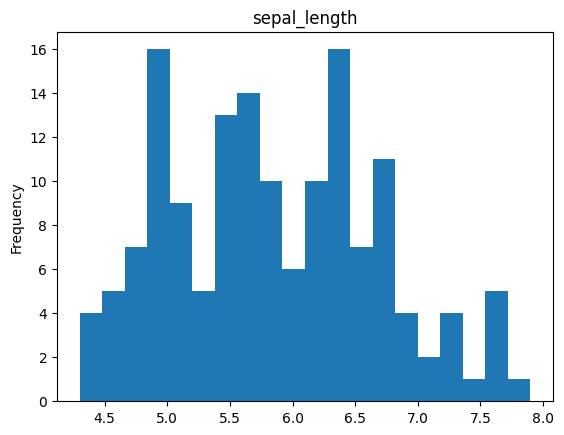

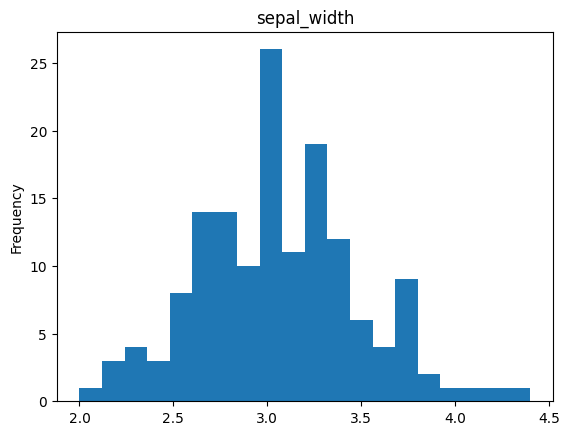

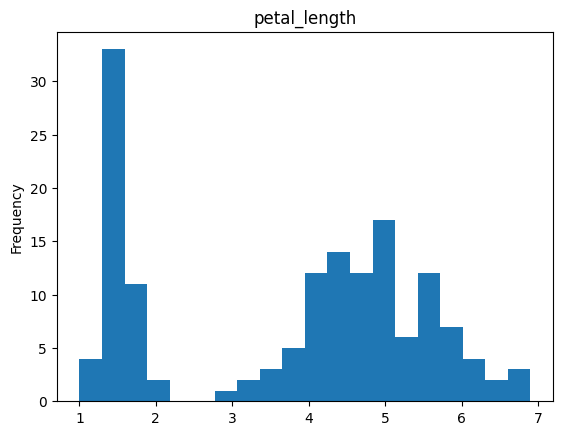

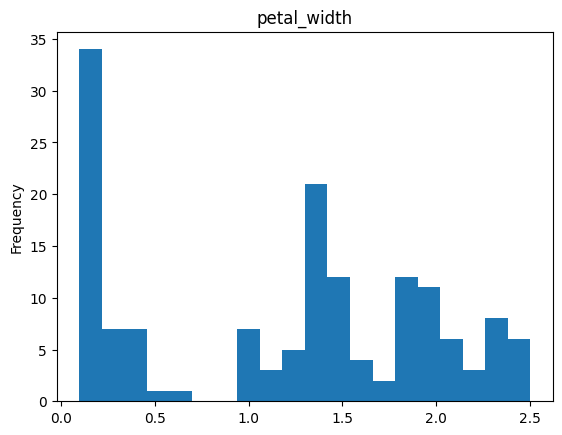

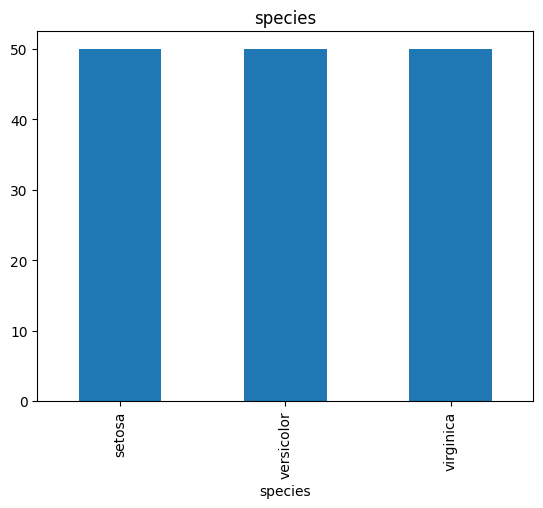

[<Figure size 640x480 with 0 Axes>,
 <Figure size 640x480 with 0 Axes>,
 <Figure size 640x480 with 0 Axes>,
 <Figure size 640x480 with 0 Axes>,
 <Figure size 640x480 with 0 Axes>]

In [108]:
# Creación de una función que, a partir de un df como parámetro, cree y exporte un gráfico automáticamente para cada columna del df
def crear_graficos_pandas(df):
    graficos = []
    
    for columna in df.columns:
        tipo_dato = df[columna].dtype
        # Gráfico de barras para variables categóricas y fechas
        if (tipo_dato == object or isinstance(tipo_dato, pd.StringDtype) or isinstance(tipo_dato, pd.CategoricalDtype) or np.issubdtype(tipo_dato, np.datetime64)):
            ax = df[columna].value_counts().plot.bar(title=columna)
            fig = ax.get_figure()
            graficos.append(fig)
            fig.savefig(f'grafico_{columna}.pdf')
            plt.show()
            fig.clf() 
            
        # Gráfico de histograma para variables numéricas (+ comprobación de que no sea boolean)
        elif np.issubdtype(tipo_dato, np.number) and not pd.api.types.is_bool_dtype(tipo_dato):
            ax = df[columna].plot.hist(bins=20, title=columna)
            fig = ax.get_figure()
            graficos.append(fig)
            fig.savefig(f'grafico_{columna}.pdf')
            plt.show()
            fig.clf() 
    
    return graficos

df_muestra = sns.load_dataset('iris')
crear_graficos_pandas(df_muestra)

#### Ejercicio 2
- A partir del archivo "matriu_distancies.xslx", crea una función que dada dicha matriz y una ciudad de origen, haga una propuesta de ruta por todas las ciudades de España que sea lo más corta posible:
    - Ha de devolver una lista con el orden de visita, así como el total de la distancia recorrida.
    - Borra las ciudades de "Palma" y "Las Palmas de Gran Canaria" para que sea posible hacerlo en coche. 

In [109]:
df_ciudades = pd.read_excel("matriu_distancies.xlsx", index_col=0)

ciudades_out = ['Las Palmas de Gran Canaria','Palma']

df_ciudades = df_ciudades.drop(ciudades_out,axis=1)
df_ciudades = df_ciudades.drop(ciudades_out,axis=0).fillna(0)

df_ciudades

,Barcelona,Valencia,Sevilla,Zaragoza,Málaga,Murcia,Bilbao,Alicante,Córdoba,Valladolid,Vigo,Gijón,Hospitalet de Llobregat
Barcelona,0.0,303.0,831.0,256.0,770.0,471.0,469.0,407.0,711.0,576.0,908.0,686.0,7.0
Valencia,303.0,0.0,541.0,246.0,468.0,177.0,473.0,125.0,421.0,441.0,766.0,632.0,297.0
Sevilla,831.0,541.0,0.0,646.0,158.0,433.0,703.0,495.0,121.0,486.0,588.0,685.0,824.0
Zaragoza,256.0,246.0,646.0,0.0,628.0,408.0,246.0,368.0,535.0,320.0,652.0,444.0,250.0
Málaga,770.0,468.0,158.0,628.0,0.0,323.0,739.0,391.0,133.0,549.0,716.0,766.0,763.0
Murcia,471.0,177.0,433.0,408.0,323.0,0.0,606.0,69.0,320.0,510.0,800.0,726.0,465.0
Bilbao,469.0,473.0,703.0,246.0,739.0,606.0,0.0,583.0,618.0,232.0,486.0,223.0,465.0
Alicante,407.0,125.0,495.0,368.0,391.0,69.0,583.0,0.0,379.0,515.0,821.0,722.0,401.0
Córdoba,711.0,421.0,121.0,535.0,133.0,320.0,618.0,379.0,0.0,419.0,589.0,634.0,704.0
Valladolid,576.0,441.0,486.0,320.0,549.0,510.0,232.0,515.0,419.0,0.0,337.0,224.0,570.0


In [110]:
def calculo_ruta(df, origen):
    '''Función para calcular la ruta más corta'''
    
    # Creamos la variables que necesitamos:
    ciudad_actual = origen     # -- Desde donde partimos (inicialmente coincide con el parámetro de entrada de la función)
    visitadas = [origen]       # -- El listado de las ciudades que visitamos para crear la ruta
    recorrido = 0              # -- Aqui iremos sumando los km según las ciudades que visitemos para obtener el total de la ruta

    # Iniciamos un bucle for que recorra la cantidad de ciudades que tengamos en el df
    for _ in range(len(df.index)):
        distancias = df.loc[ciudad_actual].drop(visitadas)    # -- Variable que guarda una serie con las ciudades aún no visitadas según la ciudad donde estemos

        if distancias.empty:                                  # -- En el momento que hayamos "dropeado" todas las ciudades, paramos el bucle porque significa que ya las hemos recorrido todas
            break

        siguiente_ciudad = distancias.idxmin()                # -- Guardamos el indice con valor mínimo (menos km) y nos devuelve la ciudad cercana a la que iremos...
        km_siguiente  = distancias.min()                      # -- ... y aqui guardamos los km que tenemos desde la ciudad en la que estamos

        visitadas.append(siguiente_ciudad)                    # -- Añadimos esa ciudad a nuestra lista de ciudades visitadas para que no vuelva a entrar en el bucle
        recorrido += km_siguiente                             # -- Sumamos los km a nuestro total
        ciudad_actual = siguiente_ciudad                      # -- Como nos hemos movido, ahora nuestra ciudad_actual es a donde hemos ido, iniciando de nuevo el bucle desde donde estamos

    return visitadas, recorrido
    
inicio = 'Alicante'
ciudades, km = calculo_ruta(df_ciudades, inicio)

print(f"Ruta desde {inicio}: {ciudades}")
print(f"Distancia recorrida: {km} km")

Ruta desde Alicante: ['Alicante', 'Murcia', 'Valencia', 'Zaragoza', 'Bilbao', 'Gijón', 'Valladolid', 'Vigo', 'Sevilla', 'Córdoba', 'Málaga', 'Hospitalet de Llobregat', 'Barcelona']
Distancia recorrida: 3134.0 km


In [111]:
# (EXTRA) Desde qué ciudad la ruta seria más corta con el algoritmo planteado.

mejor_ruta = None
menor_distancia = float("inf")  # -- Usamos infinito para comparar las distancias inicialmente, ya que cualquier distancia será menor que infinito
mejor_origen = None

# Con un bucle for recorremos las ciudades del df, y usando la función anterior que nos da la ruta y los km, revisamos ciudad por ciudad a ver cual de ellas tiene la distancia total más corta
for ciudad in df_ciudades.index:
    ruta, distancia = calculo_ruta(df_ciudades, ciudad)

    if distancia < menor_distancia: 
        menor_distancia = distancia # -- Dentro del bucle, si la distancia es menor que la variable guardada, ésta se convierte en la nueva menor_distancia
        mejor_ruta = ruta
        mejor_origen = ciudad

print(f'La ruta más corta es desde {mejor_origen}, recorriendo {menor_distancia} km: \n{mejor_ruta}')

La ruta más corta es desde Barcelona, recorriendo 2778.0 km: 
['Barcelona', 'Hospitalet de Llobregat', 'Zaragoza', 'Valencia', 'Alicante', 'Murcia', 'Córdoba', 'Sevilla', 'Málaga', 'Valladolid', 'Gijón', 'Bilbao', 'Vigo']
